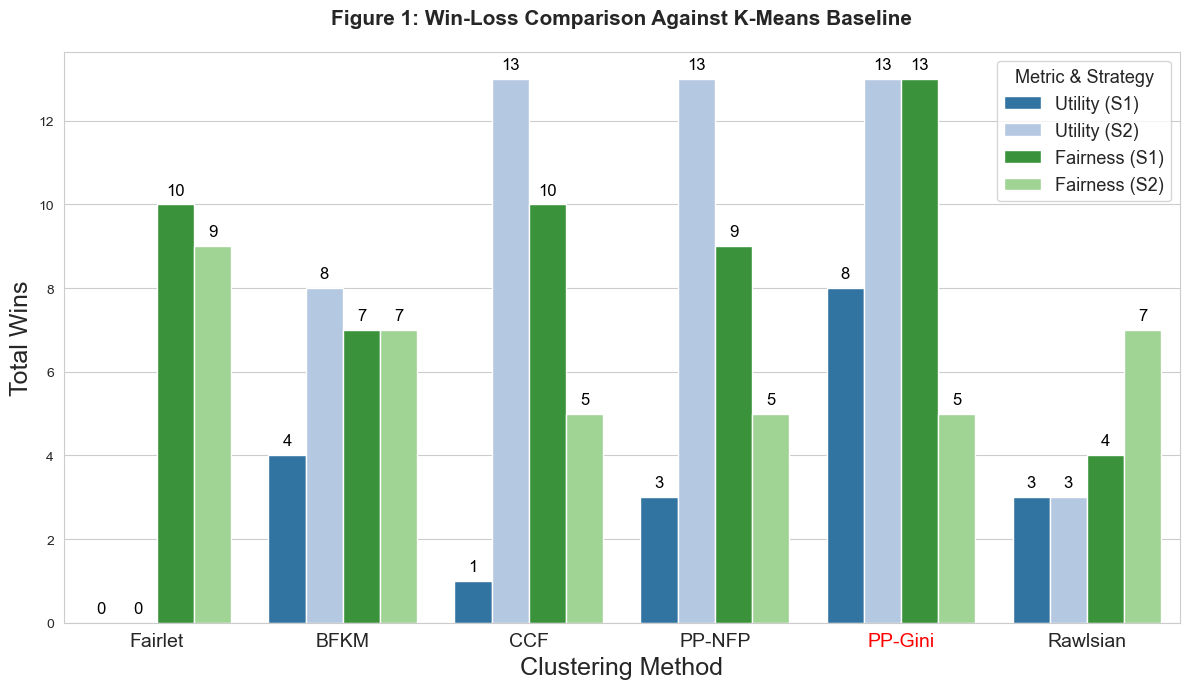

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib

matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']

data = {
    'Method': ['Fairlet', 'BFKM', 'CCF', 'PP-NFP', 'PP-Gini', 'Rawlsian'],
    'Utility (S1)': [0, 4, 1, 3, 8, 3],
    'Utility (S2)': [0, 8, 13, 13, 13, 3],
    'Fairness (S1)': [10, 7, 10, 9, 13, 4],
    'Fairness (S2)': [9, 7, 5, 5, 5, 7]
}

df = pd.DataFrame(data).melt(id_vars='Method', var_name='Metric_Strategy', value_name='Wins')

plt.figure(figsize=(12, 7), dpi=100)
sns.set_style("whitegrid")

# 3. Create the bar plot with a professional journal palette
# S1 (Darker/Muted) vs S2 (Lighter/Bright)
palette = {
    'Utility (S1)': '#1f77b4', 'Utility (S2)': '#aec7e8', 
    'Fairness (S1)': '#2ca02c', 'Fairness (S2)': '#98df8a'
}

ax = sns.barplot(data=df, x='Method', y='Wins', hue='Metric_Strategy', palette=palette)

for label in ax.get_xticklabels():
    if label.get_text() == 'PP-Gini':
        label.set_color('red') 
        label.set_fontsize(14)
    else:
        label.set_fontsize(14)


for container in ax.containers:
    labels = [f'{int(v.get_height())}' if v.get_height() >= 0 else '' for v in container]
    
    ax.bar_label(container, 
                 labels=labels, 
                 padding=5,        
                 fontsize=12,
                 color='black')

plt.title('Figure 1: Win-Loss Comparison Against K-Means Baseline', 
          fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Total Wins', fontsize=18)
plt.xlabel('Clustering Method', fontsize=18)

plt.legend(title='Metric & Strategy', 
           loc='upper right', 
           fontsize=13, 
           title_fontsize=13,
           frameon=True, 
           framealpha=0.8, 
           ncol=1)  

plt.tight_layout()
plt.savefig('Table5_Win_Loss.png')
plt.show()

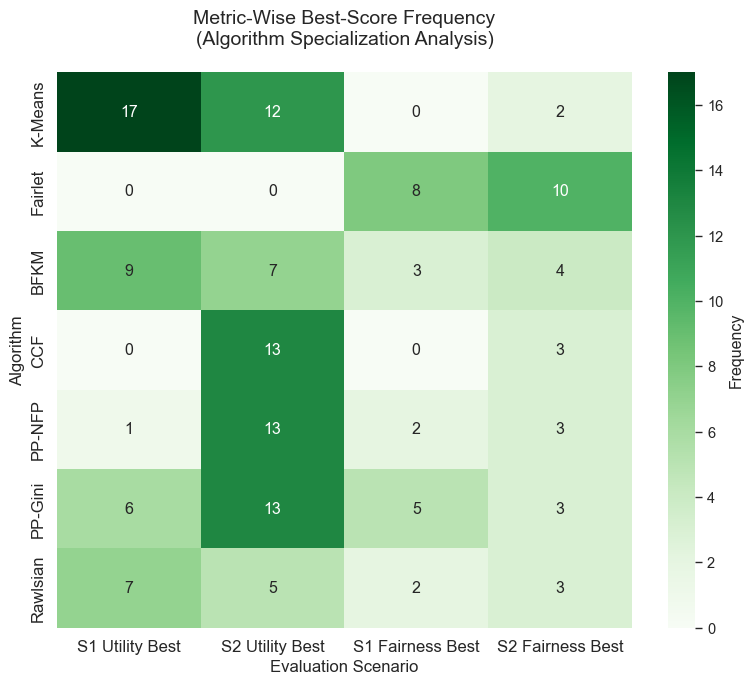

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']

algorithms = ['K-Means', 'Fairlet', 'BFKM', 'CCF', 'PP-NFP', 'PP-Gini', 'Rawlsian']
columns = ['S1 Utility Best', 'S2 Utility Best', 'S1 Fairness Best', 'S2 Fairness Best']

scores = np.array([
    [17, 12, 0, 2],   # K-Means
    [0, 0, 8, 10],    # Fairlet
    [9, 7, 3, 4],     # BFKM
    [0, 13, 0, 3],    # CCF
    [1, 13, 2, 3],    # PP-NFP
    [6, 13, 5, 3],    # PP-Gini
    [7, 5, 2, 3]      # Rawlsian
])

plt.figure(figsize=(8, 7))
sns.set_context("paper", font_scale=1.2)

ax = sns.heatmap(scores, 
                 annot=True, 
                 fmt="d", 
                 cmap="Greens", 
                 xticklabels=columns, 
                 yticklabels=algorithms, 
                 linewidths=0, 
                 # linecolor='silver',
                 cbar_kws={'label': 'Frequency'})

ax.tick_params(axis='both', which='major', labelsize=12)

plt.title('Metric-Wise Best-Score Frequency\n(Algorithm Specialization Analysis)', 
          fontsize=14, pad=20)
plt.xlabel('Evaluation Scenario', fontsize=12)
plt.ylabel('Algorithm', fontsize=12)

plt.tight_layout()
plt.savefig('Table6_Green_Heatmap.png', dpi=300) 
plt.show()

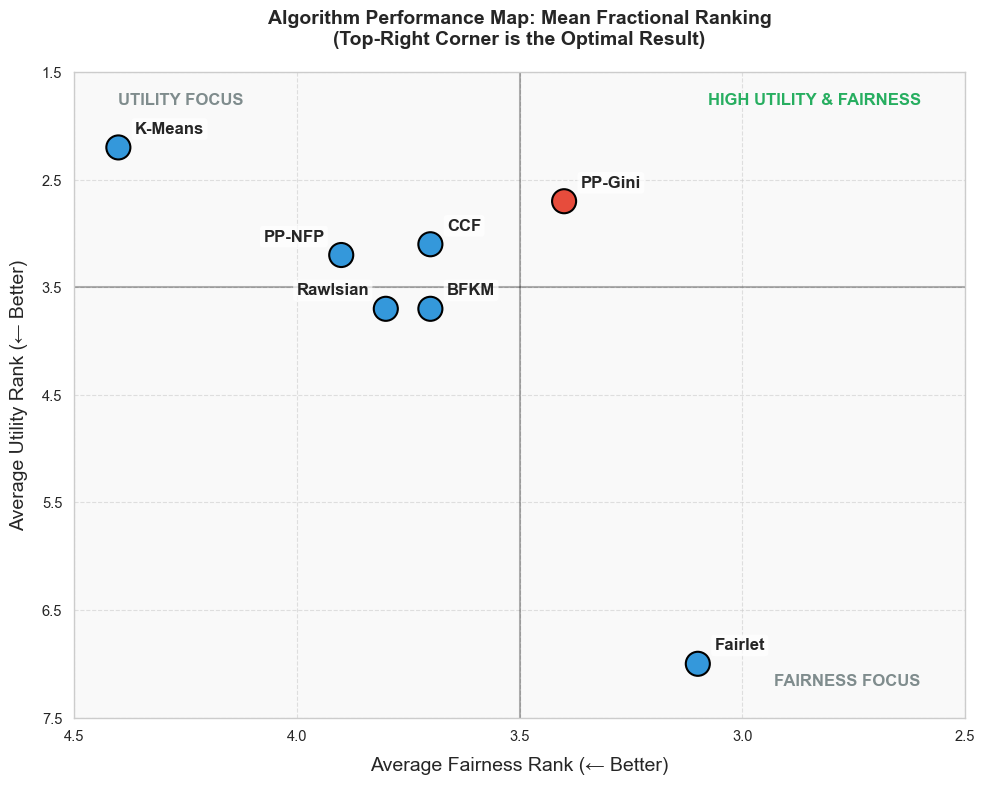

In [3]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from matplotlib.ticker import FormatStrFormatter

matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']

fairness_rank = [4.4, 3.1, 3.7, 3.7, 3.9, 3.4, 3.8] 
utility_rank = [2.2, 7.0, 3.7, 3.1, 3.2, 2.7, 3.7]
labels = ['K-Means', 'Fairlet', 'BFKM', 'CCF', 'PP-NFP', 'PP-Gini', 'Rawlsian']

plt.figure(figsize=(10, 8), dpi=100)
plt.rcParams['axes.facecolor'] = '#f9f9f9'
plt.grid(True, linestyle='--', alpha=0.6, zorder=0)

colors = ['#e74c3c' if x == 'PP-Gini' else '#3498db' for x in labels]
plt.scatter(fairness_rank, utility_rank, s=300, c=colors, edgecolors='black', linewidth=1.5, zorder=3)

for i, txt in enumerate(labels):
    x_offset = 12
    align = 'left'
    if txt in ['PP-NFP', 'Rawlsian']:
        x_offset = -12
        align = 'right'
    
    plt.annotate(txt, (fairness_rank[i], utility_rank[i]), 
                 xytext=(x_offset, 10), 
                 textcoords='offset points', 
                 fontsize=12,
                 fontweight='bold',
                 ha=align,
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none'))

plt.xlim(4.5, 3.0) 
plt.ylim(7.5, 1.5)  

plt.axvline(x=3.5, color='black', linestyle='-', linewidth=1.5, alpha=0.3)
plt.axhline(y=3.5, color='black', linestyle='-', linewidth=1.5, alpha=0.3)

plt.text(2.6, 1.8, "HIGH UTILITY & FAIRNESS", color='#27ae60', fontsize=12, fontweight='bold', ha='right')
plt.text(4.4, 1.8, "UTILITY FOCUS", color='#7f8c8d', fontsize=12, fontweight='bold', ha='left')
plt.text(2.6, 7.2, "FAIRNESS FOCUS", color='#7f8c8d', fontsize=12, fontweight='bold', ha='right')

plt.title('Algorithm Performance Map: Mean Fractional Ranking\n(Top-Right Corner is the Optimal Result)', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Average Fairness Rank (← Better)', fontsize=14, labelpad=10)
plt.ylabel('Average Utility Rank (← Better)', fontsize=14, labelpad=10)

from matplotlib.ticker import FormatStrFormatter

ax = plt.gca()
ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

import numpy as np
plt.xticks(np.arange(2.5, 4.6, 0.5)) 
plt.yticks(np.arange(1.5, 7.6, 1.0))

plt.tight_layout()
plt.savefig('Table7_MFR_v2.png')
plt.show()